# OpenVINOを使ったYolov8モデルの最適化

# 事前準備

In [1]:
%pip install -q "openvino>=2023.1.0" "nncf>=2.5.0"
%pip install -q "torch>=2.1" "torchvision>=0.16" "ultralytics==8.0.43" onnx --extra-index-url https://download.pytorch.org/whl/cpu

In [2]:
from pathlib import Path

# Fetch the notebook utils script from the openvino_notebooks repo
import urllib.request
urllib.request.urlretrieve(
    url='https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/main/notebooks/utils/notebook_utils.py',
    filename='notebook_utils.py'
)

from notebook_utils import download_file, VideoPlayer

# draw_result関数の定義

In [3]:
from typing import Tuple, Dict
import cv2
import numpy as np
from ultralytics.yolo.utils.plotting import colors


def plot_one_box(box:np.ndarray, img:np.ndarray,
                 color:Tuple[int, int, int] = None,
                 label:str = None, line_thickness:int = 5):
    """
    Helper function for drawing single bounding box on image
    Parameters:
        x (np.ndarray): bounding box coordinates in format [x1, y1, x2, y2]
        img (no.ndarray): input image
        color (Tuple[int, int, int], *optional*, None): color in BGR format for drawing box, if not specified will be selected randomly
        label (str, *optonal*, None): box label string, if not provided will not be provided as drowing result
        line_thickness (int, *optional*, 5): thickness for box drawing lines
    """
    # Plots one bounding box on image img
    tl = line_thickness or round(0.002 * (img.shape[0] + img.shape[1]) / 2) + 1  # line/font thickness
    color = color or [random.randint(0, 255) for _ in range(3)]
    c1, c2 = (int(box[0]), int(box[1])), (int(box[2]), int(box[3]))
    cv2.rectangle(img, c1, c2, color, thickness=tl, lineType=cv2.LINE_AA)
    if label:
        tf = max(tl - 1, 1)  # font thickness
        t_size = cv2.getTextSize(label, 0, fontScale=tl / 3, thickness=tf)[0]
        c2 = c1[0] + t_size[0], c1[1] - t_size[1] - 3
        cv2.rectangle(img, c1, c2, color, -1, cv2.LINE_AA)  # filled
        cv2.putText(img, label, (c1[0], c1[1] - 2), 0, tl / 3, [225, 255, 255], thickness=tf, lineType=cv2.LINE_AA)

    return img


def draw_results(results:Dict, source_image:np.ndarray, label_map:Dict):
    """
    Helper function for drawing bounding boxes on image
    Parameters:
        image_res (np.ndarray): detection predictions in format [x1, y1, x2, y2, score, label_id]
        source_image (np.ndarray): input image for drawing
        label_map; (Dict[int, str]): label_id to class name mapping
    Returns:
        Image with boxes
    """
    boxes = results["det"]
    for idx, (*xyxy, conf, lbl) in enumerate(boxes):
        label = f'{label_map[int(lbl)]} {conf:.2f}'
        source_image = plot_one_box(xyxy, source_image, label=label, color=colors(int(lbl)), line_thickness=1)
    return source_image

In [4]:
# Download a test sample
IMAGE_PATH = Path('./data/coco_bike.jpg')
download_file(
    url='https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg',
    filename=IMAGE_PATH.name,
    directory=IMAGE_PATH.parent
) 

'data/coco_bike.jpg' already exists.


PosixPath('/home/ea/work/openvino_notebooks/notebooks/230-yolov8-optimization/data/coco_bike.jpg')

# モデルのインスタンス化

In [5]:
models_dir = Path('./models')
models_dir.mkdir(exist_ok=True)

2023-10-05 19:15:51.230030: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-05 19:15:51.269549: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-05 19:15:51.909328: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Ultralytics YOLOv8.0.43 🚀 Python-3.8.10 torch-2.0.1+cpu CPU
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /home/ea/work/openvino_notebooks/notebooks/230-yolov8-optimization/data/coco_bike.jpg: 480x640 2 b

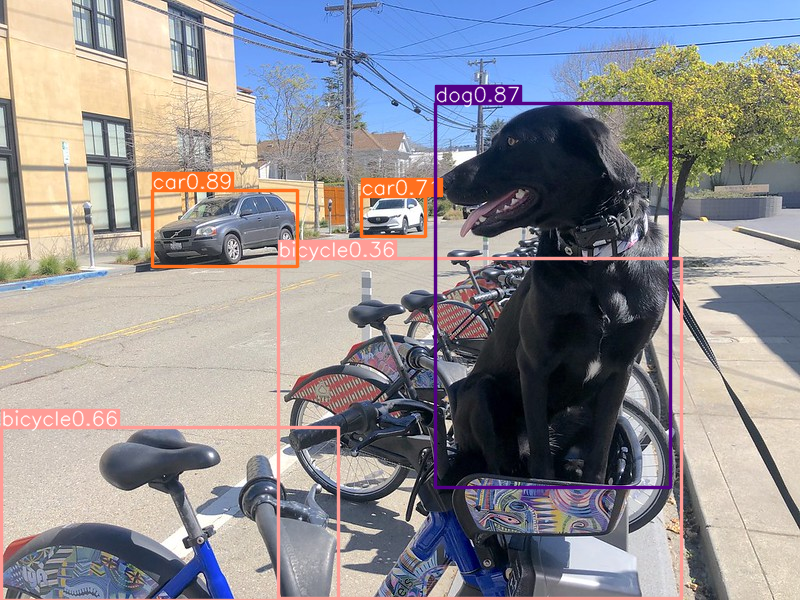

In [6]:
from PIL import Image
from ultralytics import YOLO

DET_MODEL_NAME = "yolov8n"

det_model = YOLO(models_dir / f'{DET_MODEL_NAME}.pt')
label_map = det_model.model.names

res = det_model(IMAGE_PATH)
Image.fromarray(res[0].plot()[:, :, ::-1])

# OpenVINO IR形式へ変換

In [7]:
# object detection model
det_model_path = models_dir / f"{DET_MODEL_NAME}_openvino_model/{DET_MODEL_NAME}.xml"
if not det_model_path.exists():
    det_model.export(format="openvino", dynamic=True, half=False)

# 推論精度の検証

## 事前処理
モデルの入力は `N, C, H, W` 形式の `[-1, 3, -1, -1]` 形式のテンソルです。
* `N` - バッチ内の画像数（バッチサイズ）。
* `C` - 画像のチャンネル数
* `H` - 画像の高さ
* `W` - 画像の横幅

In [8]:
from typing import Tuple
from ultralytics.yolo.utils import ops
import torch
import numpy as np


def letterbox(img: np.ndarray, new_shape:Tuple[int, int] = (640, 640), color:Tuple[int, int, int] = (114, 114, 114), auto:bool = False, scale_fill:bool = False, scaleup:bool = False, stride:int = 32):
    """
    Resize image and padding for detection. Takes image as input, 
    resizes image to fit into new shape with saving original aspect ratio and pads it to meet stride-multiple constraints
    
    Parameters:
      img (np.ndarray): image for preprocessing
      new_shape (Tuple(int, int)): image size after preprocessing in format [height, width]
      color (Tuple(int, int, int)): color for filling padded area
      auto (bool): use dynamic input size, only padding for stride constrins applied
      scale_fill (bool): scale image to fill new_shape
      scaleup (bool): allow scale image if it is lower then desired input size, can affect model accuracy
      stride (int): input padding stride
    Returns:
      img (np.ndarray): image after preprocessing
      ratio (Tuple(float, float)): hight and width scaling ratio
      padding_size (Tuple(int, int)): height and width padding size
    
    
    """
    # Resize and pad image while meeting stride-multiple constraints
    shape = img.shape[:2]  # current shape [height, width]
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)

    # Scale ratio (new / old)
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    if not scaleup:  # only scale down, do not scale up (for better test mAP)
        r = min(r, 1.0)

    # Compute padding
    ratio = r, r  # width, height ratios
    new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
    dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]  # wh padding
    if auto:  # minimum rectangle
        dw, dh = np.mod(dw, stride), np.mod(dh, stride)  # wh padding
    elif scale_fill:  # stretch
        dw, dh = 0.0, 0.0
        new_unpad = (new_shape[1], new_shape[0])
        ratio = new_shape[1] / shape[1], new_shape[0] / shape[0]  # width, height ratios

    dw /= 2  # divide padding into 2 sides
    dh /= 2

    if shape[::-1] != new_unpad:  # resize
        img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)  # add border
    return img, ratio, (dw, dh)


def preprocess_image(img0: np.ndarray):
    """
    Preprocess image according to YOLOv8 input requirements. 
    Takes image in np.array format, resizes it to specific size using letterbox resize and changes data layout from HWC to CHW.
    
    Parameters:
      img0 (np.ndarray): image for preprocessing
    Returns:
      img (np.ndarray): image after preprocessing
    """
    # resize
    img = letterbox(img0)[0]
    
    # Convert HWC to CHW
    img = img.transpose(2, 0, 1)
    img = np.ascontiguousarray(img)
    return img


def image_to_tensor(image:np.ndarray):
    """
    Preprocess image according to YOLOv8 input requirements. 
    Takes image in np.array format, resizes it to specific size using letterbox resize and changes data layout from HWC to CHW.
    
    Parameters:
      img (np.ndarray): image for preprocessing
    Returns:
      input_tensor (np.ndarray): input tensor in NCHW format with float32 values in [0, 1] range 
    """
    input_tensor = image.astype(np.float32)  # uint8 to fp32
    input_tensor /= 255.0  # 0 - 255 to 0.0 - 1.0
    
    # add batch dimension
    if input_tensor.ndim == 3:
        input_tensor = np.expand_dims(input_tensor, 0)
    return input_tensor

## 事後処理
モデルの出力には検出ボックスの候補が含まれ、 `B,84,N` 形式の `[-1,84,-1]` 形式のテンソルです。

- `B` - バッチサイズ
- `N` - 検出ボックスの数

最終的な予測値を得るためには、ultralytics.utilsにて提供される非最大抑制アルゴリズムを適用し、ボックス座標を元の画像サイズに再スケールする必要があります。
最終的に、検出ボックスは[`x`, `y`, `h`, `w`, `class_no_1`, ..., `class_no_80`] のフォーマットを持ちます。

- (`x`, `y`) - ボックス中心の生の座標
- `h`, `w` - ボックスの生の高さと幅
- `class_no_1`, ..., `class_no_80` - クラスに対する確率分布


In [9]:
def postprocess(
    pred_boxes:np.ndarray, 
    input_hw:Tuple[int, int], 
    orig_img:np.ndarray, 
    min_conf_threshold:float = 0.25, 
    nms_iou_threshold:float = 0.7, 
    agnosting_nms:bool = False, 
    max_detections:int = 300,
):
    """
    YOLOv8 model postprocessing function. Applied non maximum supression algorithm to detections and rescale boxes to original image size
    Parameters:
        pred_boxes (np.ndarray): model output prediction boxes
        input_hw (np.ndarray): preprocessed image
        orig_image (np.ndarray): image before preprocessing
        min_conf_threshold (float, *optional*, 0.25): minimal accepted confidence for object filtering
        nms_iou_threshold (float, *optional*, 0.45): minimal overlap score for removing objects duplicates in NMS
        agnostic_nms (bool, *optiona*, False): apply class agnostinc NMS approach or not
        max_detections (int, *optional*, 300):  maximum detections after NMS
    Returns:
       pred (List[Dict[str, np.ndarray]]): list of dictionary with det - detected boxes in format [x1, y1, x2, y2, score, label]
    """
    nms_kwargs = {"agnostic": agnosting_nms, "max_det":max_detections}
    preds = ops.non_max_suppression(
        torch.from_numpy(pred_boxes),
        min_conf_threshold,
        nms_iou_threshold,
        nc=80,
        **nms_kwargs
    )

    results = []
    for i, pred in enumerate(preds):
        shape = orig_img[i].shape if isinstance(orig_img, list) else orig_img.shape
        if not len(pred):
            results.append({"det": [], "segment": []})
            continue
        pred[:, :4] = ops.scale_boxes(input_hw, pred[:, :4], shape).round()
        results.append({"det": pred})

    return results

## 推論デバイスの選択

In [10]:
import ipywidgets as widgets
import openvino as ov

core = ov.Core()

device = widgets.Dropdown(
    options=core.available_devices + ["AUTO"],
    value='AUTO',
    description='Device:',
    disabled=False,
)

device

Dropdown(description='Device:', index=2, options=('CPU', 'GPU', 'AUTO'), value='AUTO')

## 単一画像でテスト

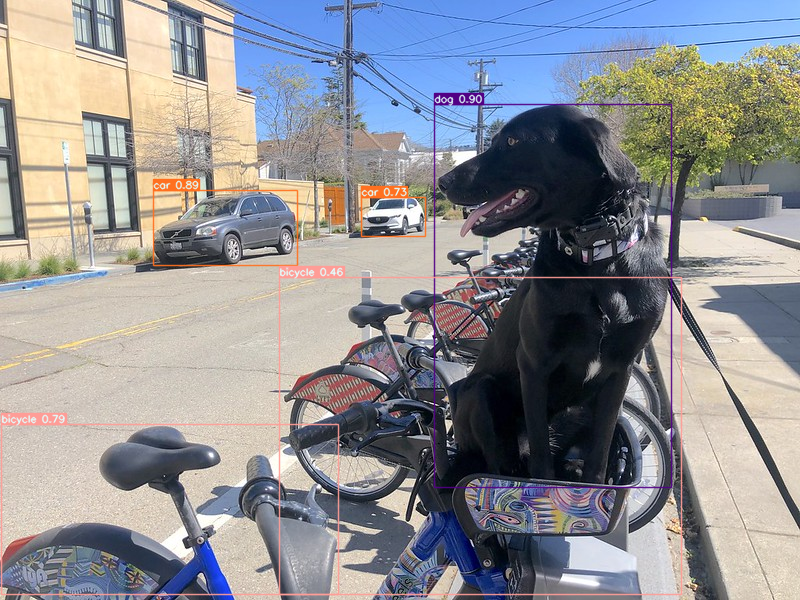

In [11]:
core = ov.Core()

det_ov_model = core.read_model(det_model_path)
if device.value != "CPU":
    det_ov_model.reshape({0: [1, 3, 640, 640]})
det_compiled_model = core.compile_model(det_ov_model, device.value)


def detect(image:np.ndarray, model:ov.Model):
    """
    OpenVINO YOLOv8 model inference function. Preprocess image, runs model inference and postprocess results using NMS.
    Parameters:
        image (np.ndarray): input image.
        model (Model): OpenVINO compiled model.
    Returns:
        detections (np.ndarray): detected boxes in format [x1, y1, x2, y2, score, label]
    """
    preprocessed_image = preprocess_image(image)
    input_tensor = image_to_tensor(preprocessed_image)
    result = model(input_tensor)
    boxes = result[model.output(0)]
    input_hw = input_tensor.shape[2:]
    detections = postprocess(pred_boxes=boxes, input_hw=input_hw, orig_img=image)
    return detections

input_image = np.array(Image.open(IMAGE_PATH))
detections = detect(input_image, det_compiled_model)[0]
image_with_boxes = draw_results(detections, input_image, label_map)

Image.fromarray(image_with_boxes)

# データセットを使用したモデル精度の確認

In [12]:
from zipfile import ZipFile

DATA_URL = "http://images.cocodataset.org/zips/val2017.zip"
LABELS_URL = "https://github.com/ultralytics/yolov5/releases/download/v1.0/coco2017labels-segments.zip"
CFG_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/8ebe94d1e928687feaa1fee6d5668987df5e43be/ultralytics/datasets/coco.yaml"

OUT_DIR = Path('./datasets')

DATA_PATH = OUT_DIR / "val2017.zip"
LABELS_PATH = OUT_DIR / "coco2017labels-segments.zip"
CFG_PATH = OUT_DIR / "coco.yaml"

download_file(DATA_URL, DATA_PATH.name, DATA_PATH.parent)
download_file(LABELS_URL, LABELS_PATH.name, LABELS_PATH.parent)
download_file(CFG_URL, CFG_PATH.name, CFG_PATH.parent)

if not (OUT_DIR / "coco/labels").exists():
    with ZipFile(LABELS_PATH , "r") as zip_ref:
        zip_ref.extractall(OUT_DIR)
    with ZipFile(DATA_PATH , "r") as zip_ref:
        zip_ref.extractall(OUT_DIR / 'coco/images')

'datasets/val2017.zip' already exists.
'datasets/coco2017labels-segments.zip' already exists.


datasets/coco.yaml:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

## 検証用のfunctionを定義


In [13]:
from tqdm.notebook import tqdm
from ultralytics.yolo.utils.metrics import ConfusionMatrix


def test(model:ov.Model, core:ov.Core, data_loader:torch.utils.data.DataLoader, validator, num_samples:int = None):
    """
    OpenVINO YOLOv8 model accuracy validation function. Runs model validation on dataset and returns metrics
    Parameters:
        model (Model): OpenVINO model
        data_loader (torch.utils.data.DataLoader): dataset loader
        validator: instance of validator class
        num_samples (int, *optional*, None): validate model only on specified number samples, if provided
    Returns:
        stats: (Dict[str, float]) - dictionary with aggregated accuracy metrics statistics, key is metric name, value is metric value
    """
    validator.seen = 0
    validator.jdict = []
    validator.stats = []
    validator.batch_i = 1
    validator.confusion_matrix = ConfusionMatrix(nc=validator.nc)
    model.reshape({0: [1, 3, -1, -1]})
    compiled_model = core.compile_model(model)
    for batch_i, batch in enumerate(tqdm(data_loader, total=num_samples)):
        if num_samples is not None and batch_i == num_samples:
            break
        batch = validator.preprocess(batch)
        results = compiled_model(batch["img"])
        preds = torch.from_numpy(results[compiled_model.output(0)])
        preds = validator.postprocess(preds)
        validator.update_metrics(preds, batch)
    stats = validator.get_stats()
    return stats


def print_stats(stats:np.ndarray, total_images:int, total_objects:int):
    """
    Helper function for printing accuracy statistic
    Parameters:
        stats: (Dict[str, float]) - dictionary with aggregated accuracy metrics statistics, key is metric name, value is metric value
        total_images (int) -  number of evaluated images
        total objects (int)
    Returns:
        None
    """
    print("Boxes:")
    mp, mr, map50, mean_ap = stats['metrics/precision(B)'], stats['metrics/recall(B)'], stats['metrics/mAP50(B)'], stats['metrics/mAP50-95(B)']
    # Print results
    s = ('%20s' + '%12s' * 6) % ('Class', 'Images', 'Labels', 'Precision', 'Recall', 'mAP@.5', 'mAP@.5:.95')
    print(s)
    pf = '%20s' + '%12i' * 2 + '%12.3g' * 4  # print format
    print(pf % ('all', total_images, total_objects, mp, mr, map50, mean_ap))
    if 'metrics/precision(M)' in stats:
        s_mp, s_mr, s_map50, s_mean_ap = stats['metrics/precision(M)'], stats['metrics/recall(M)'], stats['metrics/mAP50(M)'], stats['metrics/mAP50-95(M)']
        # Print results
        s = ('%20s' + '%12s' * 6) % ('Class', 'Images', 'Labels', 'Precision', 'Recall', 'mAP@.5', 'mAP@.5:.95')
        print(s)
        pf = '%20s' + '%12i' * 2 + '%12.3g' * 4  # print format
        print(pf % ('all', total_images, total_objects, s_mp, s_mr, s_map50, s_mean_ap))

## ValidatorとDataLoaderを定義
オリジナルのモデルリポジトリでは、精度検証パイプラインを表す `Validator` ラッパーを使用します。
このラッパーはDataLoaderと評価メトリクスを作成し、DataLoaderによって生成されたデータバッチごとにメトリクスを更新します。

さらに、データの前処理と結果の後処理も担当します。クラスの初期化には、設定を提供する必要があります。ここではデフォルトの設定を使用しますが、カスタムデータでテストするためにいくつかのパラメータをオーバーライドして置き換えることもできます。

モデルは `ValidatorClass` メソッドに接続し、バリデータクラスのインスタンスを作成します。

In [14]:
from ultralytics.yolo.utils import DEFAULT_CFG
from ultralytics.yolo.cfg import get_cfg
from ultralytics.yolo.data.utils import check_det_dataset

args = get_cfg(cfg=DEFAULT_CFG)
args.data = str(CFG_PATH)

In [15]:
det_validator = det_model.ValidatorClass(args=args)

In [16]:
det_validator.data = check_det_dataset(args.data)
det_data_loader = det_validator.get_dataloader("datasets/coco", 1)

val: Scanning datasets/coco/labels/val2017.cache... 4952 images, 48 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:00<?, ?it/s]


In [17]:
det_validator.is_coco = True
det_validator.class_map = ops.coco80_to_coco91_class()
det_validator.names = det_model.model.names
det_validator.metrics.names = det_validator.names
det_validator.nc = det_model.model.model[-1].nc

In [18]:
NUM_TEST_SAMPLES = 300

In [19]:
fp_det_stats = test(det_ov_model, core, det_data_loader, det_validator, num_samples=NUM_TEST_SAMPLES)

  0%|          | 0/300 [00:00<?, ?it/s]

In [20]:
print_stats(fp_det_stats, det_validator.seen, det_validator.nt_per_class.sum())

Boxes:
               Class      Images      Labels   Precision      Recall      mAP@.5  mAP@.5:.95
                 all         300        2145       0.594       0.543       0.579       0.417


`print_stats`は以下の精度メトリクスを出力します。

* `Precision` - 関連するオブジェクトのみを識別するモデルの正確さの度合い
* `Recall` - モデルがすべての真実のオブジェクトを検出する能力
* `t` - Intersection Over Union (IOU)の閾値で、正解と予測オブジェクトの重なりの度合い
  * `mAP@.5`は平均平均精度が0.5のIOU閾値で計算されることを示し、`mAP@.5:.95`は0.05ステップで0.5から0.95の範囲のIOU閾値で計算される。

## NNCFを使用したモデルの最適化

In [21]:
import nncf  # noqa: F811
from typing import Dict


def transform_fn(data_item:Dict):
    """
    Quantization transform function. Extracts and preprocess input data from dataloader item for quantization.
    Parameters:
       data_item: Dict with data item produced by DataLoader during iteration
    Returns:
        input_tensor: Input data for quantization
    """
    input_tensor = det_validator.preprocess(data_item)['img'].numpy()
    return input_tensor


quantization_dataset = nncf.Dataset(det_data_loader, transform_fn)

INFO:nncf:NNCF initialized successfully. Supported frameworks detected: torch, tensorflow, onnx, openvino


In [22]:
ignored_scope = nncf.IgnoredScope(
    types=["Multiply", "Subtract", "Sigmoid"],  # ignore operations
    names=[
        "/model.22/dfl/conv/Conv",           # in the post-processing subgraph
        "/model.22/Add",
        "/model.22/Add_1",
        "/model.22/Add_2",
        "/model.22/Add_3",
        "/model.22/Add_4",   
        "/model.22/Add_5",
        "/model.22/Add_6",
        "/model.22/Add_7",
        "/model.22/Add_8",
        "/model.22/Add_9",
        "/model.22/Add_10"
    ]
)


# Detection model
quantized_det_model = nncf.quantize(
    det_ov_model,
    quantization_dataset,
    preset=nncf.QuantizationPreset.MIXED,
    ignored_scope=ignored_scope
)

INFO:nncf:12 ignored nodes was found by name in the NNCFGraph
INFO:nncf:9 ignored nodes was found by types in the NNCFGraph
INFO:nncf:Not adding activation input quantizer for operation: 128 /model.22/Sigmoid
INFO:nncf:Not adding activation input quantizer for operation: 156 /model.22/dfl/conv/Conv
INFO:nncf:Not adding activation input quantizer for operation: 178 /model.22/Sub
INFO:nncf:Not adding activation input quantizer for operation: 179 /model.22/Add_10
INFO:nncf:Not adding activation input quantizer for operation: 193 /model.22/Sub_1
INFO:nncf:Not adding activation input quantizer for operation: 218 /model.22/Mul_5


Applying Fast Bias correction: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:03<00:00, 18.94it/s]


In [23]:
from openvino.runtime import serialize
int8_model_det_path = models_dir / f'{DET_MODEL_NAME}_openvino_int8_model/{DET_MODEL_NAME}.xml'
print(f"Quantized detection model will be saved to {int8_model_det_path}")
serialize(quantized_det_model, str(int8_model_det_path))

Quantized detection model will be saved to models/yolov8n_openvino_int8_model/yolov8n.xml


## 量子化したモデルの推論精度の検証

In [ ]:
device

In [1]:
if device.value != "CPU":
    quantized_det_model.reshape({0: [1, 3, 640, 640]})
quantized_det_compiled_model = core.compile_model(quantized_det_model, device.value)
input_image = np.array(Image.open(IMAGE_PATH))
detections = detect(input_image, quantized_det_compiled_model)[0]
image_with_boxes = draw_results(detections, input_image, label_map)

Image.fromarray(image_with_boxes)

NameError: name 'device' is not defined

# オリジナルのモデルと量子化したモデルの比較


In [3]:
device

NameError: name 'device' is not defined

In [2]:
# Inference FP32 model (OpenVINO IR)
!benchmark_app -m $det_model_path -d $device.value -api async -shape "[1,3,640,640]"

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
usage: benchmark_app [-h [HELP]] [-i PATHS_TO_INPUT [PATHS_TO_INPUT ...]] -m
                     PATH_TO_MODEL [-d TARGET_DEVICE]
                     [-hint {throughput,tput,cumulative_throughput,ctput,latency,none}]
                     [-niter NUMBER_ITERATIONS] [-t TIME] [-b BATCH_SIZE]
                     [-shape SHAPE] [-data_shape DATA_SHAPE] [-layout LAYOUT]
                     [-extensions EXTENSIONS] [-c PATH_TO_CLDNN_CONFIG]
                     [-cdir CACHE_DIR] [-lfile [LOAD_FROM_FILE]]
                     [-api {sync,async}] [-nireq NUMBER_INFER_REQUESTS]
                     [-nstreams NUMBER_STREAMS]
                     [-inference_only [INFERENCE_ONLY]]
                     [-infer_precision INFER_PRECISION]
                     [-ip {bool,f16,f32,f64,i8,i16,i32,i64,u8,u16,u32,u64}]
                     [-op {bool,f16,f32,f64,i8,i16,i32,i64,u8,u16,u32,u64}]
                     [-

In [28]:
# Inference INT8 model (OpenVINO IR)
!benchmark_app -m $int8_model_det_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2023.2.0-12690-0ee0b4d9561
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2023.2.0-12690-0ee0b4d9561
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 73.93 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     images (node: images) : f32 / [...] / [1,3,?,?]
[ INFO ] Model outputs:
[ INFO ]     output0 (node: output0) : f32 / [...] / [1,84,21..]
[Step 5/11] Resizing model to match image sizes and given batch
[ INFO ] Model batch size: 1
[ INFO ] Reshaping model: 'images': [1,3,640,640]
[

## 量子化したモデルの精度の検証

In [30]:
int8_det_stats = test(quantized_det_model, core, det_data_loader, det_validator, num_samples=NUM_TEST_SAMPLES)

print("FP32 model accuracy")
print_stats(fp_det_stats, det_validator.seen, det_validator.nt_per_class.sum())

print("INT8 model accuracy")
print_stats(int8_det_stats, det_validator.seen, det_validator.nt_per_class.sum())

FP32 model accuracy
Boxes:
               Class      Images      Labels   Precision      Recall      mAP@.5  mAP@.5:.95
                 all         300        2145       0.594       0.543       0.579       0.417
INT8 model accuracy
Boxes:
               Class      Images      Labels   Precision      Recall      mAP@.5  mAP@.5:.95
                 all         300        2145       0.623       0.517       0.572       0.406


# 事前処理をモデルへ統合

## PrePostProcessing APIの初期化

In [31]:
from openvino.preprocess import PrePostProcessor

ppp = PrePostProcessor(quantized_det_model)

## モデルの入力データフォーマットの定義
`input_id` は `model.inputs` 内の入力の位置インデックスまたは入力テンソル名で、入力が1つのモデルの場合は `input_id` は省略できます。
ディスクから画像を読み込んだ後、画像は `[0, 255]` の範囲の U8 ピクセルを含み、`NHWC` レイアウトに格納されます。
前処理の変換を行うには、これをテンソルの記述に与える必要があります。

In [32]:
ppp.input(0).tensor().set_shape([1, 640, 640, 3]).set_element_type(ov.Type.u8).set_layout(ov.Layout('NHWC'))
pass

ppp.input(0).preprocess().convert_element_type(ov.Type.f32).convert_layout(ov.Layout('NCHW')).scale([255., 255., 255.])

print(ppp)

## モデルへ統合

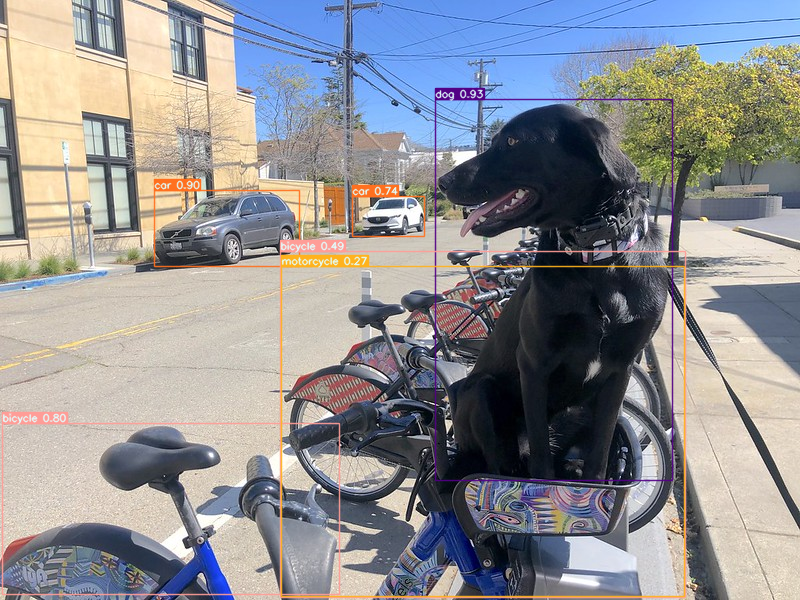

In [35]:
quantized_model_with_preprocess = ppp.build()
serialize(quantized_model_with_preprocess, str(int8_model_det_path.with_name(f"{DET_MODEL_NAME}_with_preprocess.xml")))

def detect_without_preprocess(image:np.ndarray, model:ov.Model):
    """
    OpenVINO YOLOv8 model with integrated preprocessing inference function. Preprocess image, runs model inference and postprocess results using NMS.
    Parameters:
        image (np.ndarray): input image.
        model (Model): OpenVINO compiled model.
    Returns:
        detections (np.ndarray): detected boxes in format [x1, y1, x2, y2, score, label]
    """
    output_layer = model.output(0)
    img = letterbox(image)[0]
    input_tensor = np.expand_dims(img, 0)
    input_hw = img.shape[:2]
    result = model(input_tensor)[output_layer]
    detections = postprocess(result, input_hw, image)
    return detections


compiled_model = core.compile_model(quantized_model_with_preprocess, device.value)
input_image = np.array(Image.open(IMAGE_PATH))
detections = detect_without_preprocess(input_image, compiled_model)[0]
image_with_boxes = draw_results(detections, input_image, label_map)

Image.fromarray(image_with_boxes)